In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import os

_, name = os.path.split(os.getcwd())
if name=="notebooks":
    os.chdir("../.")

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Real data

### Probe measurements

we now consider probe vehicles

/home/julien_moreau_renault_com/traffic-models/.venv/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)


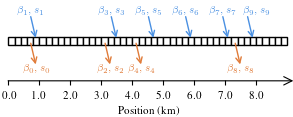

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl

from traffic_models.experiment.probe_data import prepare_probe_experiment_data
from traffic_models.experiment.probe_experiment import DatasetConfig, ProbeExperimentConfig
from traffic_models.data.mobile_century_mapped import mobile_century_ramp_indexes

conf = ProbeExperimentConfig(
    dt_seconds=5,
    dx_meters=200,
    seed=0,
    # dt_seconds=5,
    # dx_meters=200,
    data=DatasetConfig(
        name="mobile-century",
        path="data/mobilecentury/NB_veh_files",
        probe_fraction=0.1,
        boundary_fraction=1.0,
        # start_seconds=18_000, end_seconds=24_000,
        start_seconds=1_600, end_seconds=32_000, xmin_meters=34_000, xmax_meters=43_000,
        # start_seconds=1_600, end_seconds=32_000, xmin_meters=34_000, xmax_meters=43_000,
        # start_seconds=18_000, end_seconds=24_000, xmin_meters=34_000, xmax_meters=43_000,
        # start_seconds=30_000, end_seconds=30_400, xmin_meters=34_000, xmax_meters=40_000,
        smoothing=True,
    ),
)

conf.kalman.velocity_model_variance=0.1
grid, discretized_trajectories, full_trajectories, fields = prepare_probe_experiment_data(conf)
measured_v = np.zeros((grid.n_timesteps, grid.n_cells)) * np.nan
measured_v[discretized_trajectories["t_index"], discretized_trajectories["x_index"]] = (
    discretized_trajectories["velocity"]
)

if conf.data.name=="mobile-century":
    on_ramps_index, off_ramps_index = mobile_century_ramp_indexes(grid, conf.data.xmin_meters)
else:
    on_ramps_index, off_ramps_index = np.empty(0,dtype=int), np.empty(0,dtype=int)
from traffic_models.data.mobile_century_mapped import mobile_century_ramp_indexes
from traffic_models.plot.ctm_graph import line_layout
from traffic_models.plot.utils import rcparams
import networkx as nx
from matplotlib.patches import Rectangle
plt.rcParams.update(rcparams(subplots=(2,3),ieee=True,columns=1))

def line_layout(g: nx.Graph) -> dict:
    layout = {}
    xs = [data["x_meters"] for _, data in g.nodes.items()]
    min_x, max_x = min(xs), max(xs)
    length = max_x - min_x
    
    for i, (node, data) in enumerate(g.nodes.items()):
        x = data["x_meters"]
        is_onramp = data["is_on_ramp"]
        is_offramp = data["is_off_ramp"]
        delta = 1 if is_onramp else (-1 if is_offramp else 0.0)
        y = delta * 1e-1
        layout[node] = [x, y]
    return layout


G = nx.from_numpy_array(np.eye(grid.n_cells,grid.n_cells, 1), create_using=nx.DiGraph)
x_map: dict = {n: n+1/2 for n in range(grid.n_cells)}
nx.set_node_attributes(G, x_map, "x_meters")
nx.set_node_attributes(G, False, "is_on_ramp")
nx.set_node_attributes(G, False, "is_off_ramp")
nx.set_node_attributes(G, "motorway", "category")
G.add_edges_from([(r, k) for k,r in zip(on_ramps_index, 100+on_ramps_index)])
G.add_edges_from([(k, r) for k,r in zip(off_ramps_index, 100+off_ramps_index)])
G.add_nodes_from([(100+k, dict(x_meters=k-1/2, category="on_ramp", is_on_ramp=True, is_off_ramp=False)) for k in on_ramps_index])
G.add_nodes_from([(100+k, dict(x_meters=k+3/2, category="off_ramp", is_off_ramp=True, is_on_ramp=False)) for k in off_ramps_index])

all_ramps_sorted = sorted([(pos, 'on') for pos in on_ramps_index] + [(pos, 'off') for pos in off_ramps_index])
on_ramp_indices = {pos: i for i, (pos, rtype) in enumerate(all_ramps_sorted) if rtype == 'on'}
off_ramp_indices = {pos: i for i, (pos, rtype) in enumerate(all_ramps_sorted) if rtype == 'off'}

fig, ax = plt.subplots()

cell_height = 0.03
for n in range(grid.n_cells):
    ax.add_patch(Rectangle(
        (n, -cell_height / 2), 1.0, cell_height,
        linewidth=1, edgecolor="black", facecolor="white",
    ))

layout = line_layout(G)
for u, v in G.edges():
    u_cat, v_cat = G.nodes[u]["category"], G.nodes[v]["category"]
    if u_cat == "on_ramp" or v_cat == "on_ramp":
        color = "#4A90E2"
    elif u_cat == "off_ramp" or v_cat == "off_ramp":
        color = "#E07B39"
    else:
        continue
    ax.annotate("", xy=layout[v], xytext=layout[u],
                arrowprops=dict(arrowstyle="->", color=color, lw=1, mutation_scale=10))

x_min = min([G.nodes[n]["x_meters"] for n in G.nodes() if G.nodes[n]["category"] == "motorway"])
x_max = max([G.nodes[n]["x_meters"] for n in G.nodes() if G.nodes[n]["category"] == "motorway"])
ax.set_xlim(x_min - 1, x_max + 1)
ax.set_ylim(-0.15, 0.15)

for ramp_idx in on_ramps_index:
    x_pos = ramp_idx+1/2
    i = on_ramp_indices[ramp_idx]
    if i == 9:
        x_pos += 1.5
    ax.text(x_pos-0.95, 0.10, r"$\beta_{}, s_{}$".format(i,i), ha="center", va="bottom", fontsize=7, color="#4A90E2")

for ramp_idx in off_ramps_index:
    x_pos = ramp_idx+1/2
    i = off_ramp_indices[ramp_idx]
    ax.text(x_pos+1.0, -0.12, r"$\beta_{}, s_{}$".format(i,i), ha="center", va="bottom", fontsize=7, color="#E07B39")


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_yticks([])

xticks_cells = np.arange(0, grid.n_cells, max(1, grid.n_cells // 8))
xticks_km = xticks_cells * grid.dx_meters / 1000
ax.set_xticks(xticks_cells)
ax.set_xticklabels([f"{x:.1f}" for x in xticks_km])
ax.set_xlabel("Position (km)")
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_label_position('bottom')
ax.tick_params(axis='x', labelsize=8)
def add_xaxis_arrow(ax: plt.Axes) -> None:
    ax.annotate(
        "",
        xy=(1.02, -0.005),
        xycoords="axes fraction",
        xytext=(0.0, -0.005),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color="black", mutation_scale=15),
        clip_on=False,
    )

add_xaxis_arrow(ax)
limits=plt.axis('on')
# plt.tight_layout()
plt.savefig("output_plots/itsc/ramp_diagram.pdf", dpi=600);


/var/tmp/ipykernel_888610/371383514.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


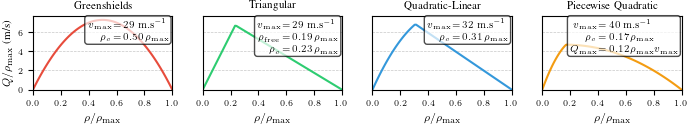

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from traffic_models.flows_default import greenshields_mobile_century_herrera_bayen_2010, triangular_mobile_century_herrera_bayen_2010, quadraticlinear_mobile_century_herrera_bayen_2010
from traffic_models.flows import GreenshieldsFlow, TriangularFlow, QuadraticLinearFlow, PiecewiseQuadraticFlow
from traffic_models.plot.utils import rcparams
plt.rcParams.update(rcparams(subplots=(1,3),ieee=True,columns=2))

def param_lines(flow: object) -> list[str]:
    rows = [rf"v_{{\max}} & {flow.v_max:.2g}\;\mathrm{{m.s^{{-1}}}}"]
    if hasattr(flow, "rho_free_flow"):
        rows.append(rf"\rho_{{\mathrm{{free}}}} & {flow.rho_free_flow / flow.rho_max:.2f}\,\rho_{{\max}}")
    if hasattr(flow, "rho_c"):
        rows.append(rf"\rho_c & {flow.rho_c / flow.rho_max:.2f}\,\rho_{{\max}}")
    if hasattr(flow, "Q_max"):
        rows.append(rf"Q_{{\max}} & {flow.Q_max / (flow.rho_max * flow.v_max):.2f}\,\rho_{{\max}}v_{{\max}}")
    return [r"$\begin{array}{r@{\,=\,}l}" + r"\\".join(rows) + r"\end{array}$"]

flows_labels_colors = [
    (greenshields_mobile_century_herrera_bayen_2010(), "Greenshields", "#E74C3C"),
    (triangular_mobile_century_herrera_bayen_2010(), "Triangular", "#2ECC71"),
    (QuadraticLinearFlow(v_max=32, rho_max=0.094, rho_c=0.04*0.094/0.13), "Quadratic-Linear", "#3498DB"),
    (PiecewiseQuadraticFlow(v_max=40,rho_max=0.094,rho_c=0.016,Q_max=0.44), "Piecewise Quadratic", "#F39C12"),
]

rho_arrays = [np.linspace(0, 1, 100) for flow, _, _ in flows_labels_colors]
q_arrays = [flow(r * flow.rho_max) / flow.rho_max for (flow, _, _), r in zip(flows_labels_colors, rho_arrays)]
y_min = min(q.min() for q in q_arrays)
y_max = max(q.max() * 1.05 for q in q_arrays)
x_max = max(flow.rho_max for flow, _, _ in flows_labels_colors)

fig, axes = plt.subplots(1, 4)
for i, (ax, (flow, label, color), r, q) in enumerate(zip(axes.flat, flows_labels_colors, rho_arrays, q_arrays)):
    ax.plot(r, q, color=color)
    ax.set_title(label)
    ax.set_xlabel(r"$\rho/\rho_{\max}$")
    ax.set_xlim(0, 1)
    ax.set_ylim(y_min, y_max)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)
    if i == 0:
        ax.set_ylabel(r"$Q/\rho_{\max}$ (m/s)")
    else:
        ax.tick_params(left=False, labelleft=False)
    ax.text(0.97, 0.97, "\n".join(param_lines(flow)), transform=ax.transAxes,
            fontsize=7, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
plt.tight_layout()
plt.savefig("output_plots/itsc/fundamental_diagrams.pdf", dpi=600);

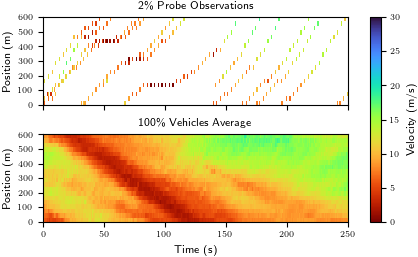

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl

from traffic_models.experiment.probe_data import prepare_probe_experiment_data
from traffic_models.experiment.probe_experiment import DatasetConfig, ProbeExperimentConfig
from traffic_models.data.mobile_century_mapped import mobile_century_ramp_indexes

conf = ProbeExperimentConfig(
    dt_seconds=1,
    dx_meters=30,
    data = DatasetConfig(
        name="us-101",
        # start_seconds=180,  # start 3 minutes after the beginning
        # end_seconds=2700,
        start_seconds=750,  # zooming
        end_seconds=1000,  # 
        probe_fraction=0.02,
        boundary_fraction=0.0,
        smoothing=False
    )
)

grid, discretized_trajectories, full_trajectories, fields = prepare_probe_experiment_data(conf)
measured_v = np.zeros((grid.n_timesteps, grid.n_cells)) * np.nan
measured_v[discretized_trajectories["t_index"], discretized_trajectories["x_index"]] = (
    discretized_trajectories["velocity"]
)

from traffic_models.plot.utils import rcparams
plt.rcParams.update(rcparams(
    beamer=True,
))
fig, axes = plt.subplots(2,1)
_ = axes[0].matshow(measured_v.T, aspect="auto", origin="lower",cmap="turbo_r", extent=[0, grid.n_timesteps*conf.dt_seconds, 0, grid.n_cells*conf.dx_meters],vmin=0, vmax=30)
ms = axes[1].matshow(fields.speed.T, aspect="auto", origin="lower",cmap="turbo_r", extent=[0, grid.n_timesteps*conf.dt_seconds, 0, grid.n_cells*conf.dx_meters],vmin=0, vmax=30)
fig.colorbar(ms, ax=[axes[0],axes[1]],label="Velocity (m/s)")
axes[0].set_title(r"2\% Probe Observations")
axes[1].set_title(r"100\% Vehicles Average")
for ax in axes:
    ax.xaxis.set_ticks_position("bottom")
axes[0].tick_params(axis="x", which="both", bottom=True, labelbottom=False)
axes[0].set_ylabel("Position (m)")
axes[1].set_ylabel("Position (m)")
axes[1].set_xlabel("Time (s)")
# axes[0].colorbar(label="Speed (m/s)")
plt.savefig("output_plots/beamer/ngsim_task.pdf", dpi=600);